<a href="https://colab.research.google.com/github/ugisrutinsRSU/RSU/blob/main/03_Simple_Neural_Network_Numpy_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Neural Network — NumPy, Binary Classification

This is a **simpler version** of the NumPy neural network.
Instead of 2 output neurons + softmax (as in the PyTorch version), we use:
- **1 output neuron** with sigmoid
- **Binary cross-entropy loss**
- Labels stay as plain 0/1 integers — no one-hot encoding needed

**Architecture:** 10 → 16 → 8 → **1**

**Steps:**
1. Data: generate, split, normalise
2. Activation functions and their derivatives
3. Initialise weights
4. Forward pass
5. Loss function
6. Backward pass (backpropagation)
7. Training loop
8. Evaluation: classification report, confusion matrix, learning curves

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

### Step 1: Data — Generate, Split, Normalise

In [ ]:
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")

X_train: (800, 10)   y_train: (800,)


### Why no one-hot encoding?

In the **PyTorch version**, the network has 2 output neurons and uses `CrossEntropyLoss`,
which expects a probability distribution over both classes — so labels must be one-hot vectors.

Here we use a **single output neuron** with sigmoid, which directly outputs  
one probability p ∈ (0, 1): *how likely is this sample class 1?*  
Binary cross-entropy then compares that scalar to the label (0 or 1) directly.

Labels stay as plain integers — no conversion needed.

```python
# The PyTorch-style approach (2 outputs + one-hot) — not needed here:
# def to_one_hot(labels, num_classes=2):
#     one_hot = np.zeros((len(labels), num_classes))
#     one_hot[np.arange(len(labels)), labels] = 1
#     return one_hot
# y_train_oh = to_one_hot(y_train)   # shape (800, 2)
# y_test_oh  = to_one_hot(y_test)    # shape (200, 2)
```

### Step 2: Activation Functions

- **ReLU** — used in hidden layers
- **Sigmoid** — used in the output layer; squashes any value to (0, 1)

We need the derivative of both for backpropagation.

In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid: s(z) * (1 - s(z))."""
    s = sigmoid(z)
    return s * (1 - s)

### Step 3: Initialise Weights

He initialisation for ReLU layers. The output layer now has only **1 neuron**.

In [ ]:
def init_weights(layer_sizes):
    """
    layer_sizes: e.g. [10, 16, 8, 1]
    Returns a list of (W, b) pairs, one per layer transition.
    """
    params = []
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
        b = np.zeros((1, fan_out))
        params.append((W, b))
    return params

params = init_weights([10, 16, 8, 1])   # note: 1 output neuron

for i, (W, b) in enumerate(params):
    print(f"Layer {i+1}: W {W.shape}  b {b.shape}")

Layer 1: W (10, 16)  b (1, 16)
Layer 2: W (16, 8)  b (1, 8)
Layer 3: W (8, 1)  b (1, 1)


### Step 4: Forward Pass

Hidden layers use ReLU. The final layer uses sigmoid to produce a single probability.

In [ ]:
def forward(X, params):
    """
    Returns:
        probs  — sigmoid output, shape (n, 1)
        cache  — list of (Z, A) per layer, needed for backprop
    """
    cache = []
    A = X
    for i, (W, b) in enumerate(params):
        Z = A @ W + b
        A = sigmoid(Z) if i == len(params) - 1 else relu(Z)
        cache.append((Z, A))
    return A, cache

### Step 5: Loss — Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{n} \sum_{i} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

This is the scalar version of cross-entropy for a single output neuron.

In [ ]:
def binary_cross_entropy(probs, y):
    """
    probs: shape (n, 1)
    y:     shape (n,) — plain 0/1 labels
    """
    p = np.clip(probs.squeeze(), 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

### Step 6: Backward Pass — Backpropagation

For **sigmoid + binary cross-entropy**, the output gradient simplifies to:
$$\delta^{\text{out}} = \hat{y} - y$$
— the same clean form as softmax + cross-entropy in the PyTorch version.

Hidden layers use the ReLU derivative as before.

In [ ]:
def backward(X, y, params, cache):
    """
    y: shape (n,) — plain labels
    Returns gradients as a list of (dW, db) pairs.
    """
    n = X.shape[0]
    grads = [None] * len(params)

    # Output gradient: sigmoid + binary cross-entropy
    probs = cache[-1][1].squeeze()         # shape (n,)
    dA = ((probs - y) / n).reshape(-1, 1)  # shape (n, 1)

    for i in reversed(range(len(params))):
        A_prev = cache[i - 1][1] if i > 0 else X

        dW = A_prev.T @ dA
        db = dA.sum(axis=0, keepdims=True)
        grads[i] = (dW, db)

        if i > 0:
            W_curr = params[i][0]
            Z_prev = cache[i - 1][0]   # pre-activation of the previous layer
            dA = (dA @ W_curr.T) * relu_derivative(Z_prev)

    return grads

### Step 7: Training Loop

Mini-batch gradient descent — same structure as before.
Predictions are made by thresholding sigmoid output at 0.5.

In [ ]:
def get_batches(X, y, batch_size):
    idx = np.random.permutation(len(X))
    for start in range(0, len(X), batch_size):
        batch = idx[start:start + batch_size]
        yield X[batch], y[batch]

def compute_accuracy(X, y, params):
    probs, _ = forward(X, params)
    preds = (probs.squeeze() >= 0.5).astype(int)   # threshold at 0.5
    return (preds == y).mean()

In [ ]:
LR         = 0.01
EPOCHS     = 20
BATCH_SIZE = 32

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):

    for X_batch, y_batch in get_batches(X_train, y_train, BATCH_SIZE):
        probs, cache = forward(X_batch, params)
        grads = backward(X_batch, y_batch, params, cache)
        params = [(W - LR * dW, b - LR * db)
                  for (W, b), (dW, db) in zip(params, grads)]

    train_probs, _ = forward(X_train, params)
    test_probs,  _ = forward(X_test,  params)

    train_loss = binary_cross_entropy(train_probs, y_train)
    test_loss  = binary_cross_entropy(test_probs,  y_test)
    train_acc  = compute_accuracy(X_train, y_train, params)
    test_acc   = compute_accuracy(X_test,  y_test,  params)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss: {train_loss:.4f}  test_loss: {test_loss:.4f}  "
          f"test_acc: {test_acc:.4f}")

Epoch  1/20  train_loss: 0.6949  test_loss: 0.7138  test_acc: 0.5300
Epoch  2/20  train_loss: 0.6655  test_loss: 0.6796  test_acc: 0.6400
Epoch  3/20  train_loss: 0.6459  test_loss: 0.6566  test_acc: 0.6650
Epoch  4/20  train_loss: 0.6311  test_loss: 0.6393  test_acc: 0.6800
Epoch  5/20  train_loss: 0.6182  test_loss: 0.6243  test_acc: 0.6800
Epoch  6/20  train_loss: 0.6064  test_loss: 0.6112  test_acc: 0.7050
Epoch  7/20  train_loss: 0.5946  test_loss: 0.5985  test_acc: 0.7150
Epoch  8/20  train_loss: 0.5825  test_loss: 0.5858  test_acc: 0.7100
Epoch  9/20  train_loss: 0.5700  test_loss: 0.5730  test_acc: 0.7300
Epoch 10/20  train_loss: 0.5570  test_loss: 0.5600  test_acc: 0.7300
Epoch 11/20  train_loss: 0.5436  test_loss: 0.5466  test_acc: 0.7250
Epoch 12/20  train_loss: 0.5298  test_loss: 0.5332  test_acc: 0.7550
Epoch 13/20  train_loss: 0.5158  test_loss: 0.5197  test_acc: 0.7550
Epoch 14/20  train_loss: 0.5016  test_loss: 0.5062  test_acc: 0.7700
Epoch 15/20  train_loss: 0.4875  t

### Step 8: Evaluate the Model

In [ ]:
probs, _ = forward(X_test, params)
y_pred   = (probs.squeeze() >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

              precision    recall  f1-score   support

     Class 0       0.75      0.83      0.79        89
     Class 1       0.85      0.77      0.81       111

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.81      0.80      0.80       200



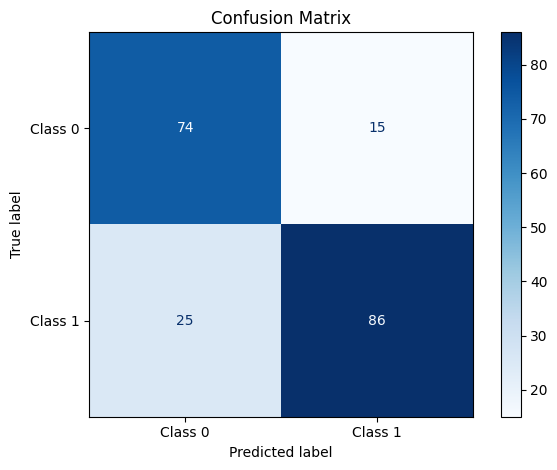

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Class 0", "Class 1"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

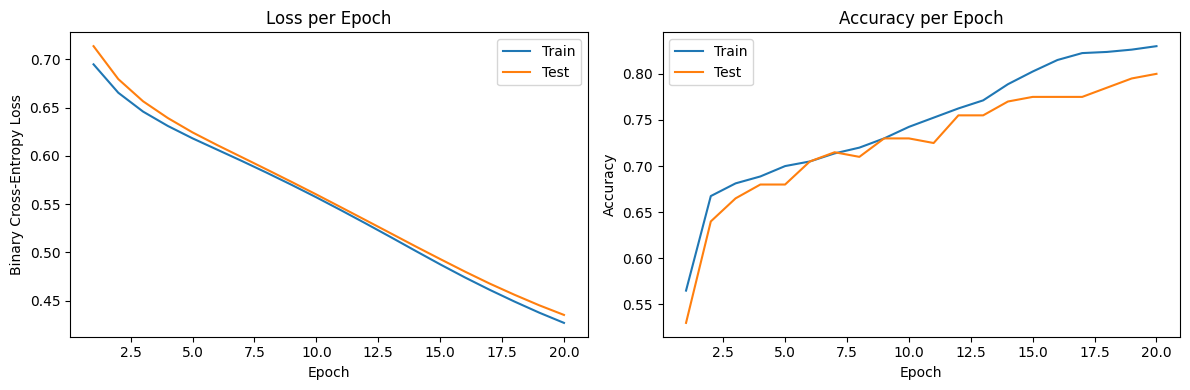

In [ ]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"],  label="Test")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["test_acc"],  label="Test")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()